#  Introduction & Setup

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def load_train_data(file):
  '''
  Load train data and define target variable
  '''
  col_names = (['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
          [f'sensor_{i+1}' for i in range(21)])
  df = pd.read_csv(file, sep=r'\s+', header=None, names=col_names)
  # Define target variable (Piecewise RUL capped at 125)
  max_cycle = df.groupby('unit')['cycle'].max()
  df['max_cycle'] = df['unit'].map(max_cycle) # mapping unit to max_cycle
  df['RUL'] = df['max_cycle'] - df['cycle']
  df['RUL_piecewise'] = df['RUL'].clip(upper=125)
  df.drop('max_cycle', axis=1, inplace=True)
  return df

In [ ]:
def load_test_data(file, rul):
  '''
  Load test data and define target variable
  '''
  col_names = (['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
          [f'sensor_{i+1}' for i in range(21)])

  df = pd.read_csv(file, sep=r'\s+', header=None, names=col_names)
  rul_df = pd.read_csv(rul, header=None, names=['RUL'])
  rul_df.index += 1

  df['max_cycle'] = df['unit'].map(df.groupby('unit')['cycle'].max())
  # The True RUL at any given cycle = (Max Cycle - Current Cycle) + Final Ground Truth RUL
  df['True_RUL'] = (df['max_cycle'] - df['cycle']) + df['unit'].map(rul_df['RUL'])
  df['True_RUL_piecewise'] = df['True_RUL'].clip(upper=125)
  df.drop('max_cycle', axis=1, inplace=True)

  return df

In [ ]:
def normalize_train_data(df, sensors, kmeans):
  '''
  Normalize train data by regime (flight regime)
  '''
  df['flight_regime'] = kmeans.fit_predict(df[['op_setting_1', 'op_setting_2', 'op_setting_3']])

  normalized_cols = [f'{sensor}_norm' for sensor in sensors]
  # Initialize empty columns for the normalized data
  for col in normalized_cols:
    df[col] = 0.0

  # Dictionary to save all scalers
  regime_scalers = {}

  # Loop through each of the 6 flight regimes
  for regime in df['flight_regime'].unique():
    scaler = StandardScaler()

    # 1. Isolate the training data for a regime
    regime_mask = df['flight_regime'] == regime

    # 2. Fit and transform only on the training data
    df.loc[regime_mask, normalized_cols] = scaler.fit_transform(df.loc[regime_mask, sensors])

    # 3. Save the fitted scaler into our dictionary
    regime_scalers[regime] = scaler

  return normalized_cols, regime_scalers

In [ ]:
def normalize_test_data(df, sensors, kmeans, regime_scalers):
  '''
  Normalize test data by regime found in train data
  '''
  df['flight_regime'] = kmeans.predict(df[['op_setting_1', 'op_setting_2', 'op_setting_3']])

  normalized_cols = [f'{sensor}_norm' for sensor in sensors]
  # Initialize empty columns for the normalized data
  for col in normalized_cols:
    df[col] = 0.0

  # Loop through the test regimes
  for regime in df['flight_regime'].unique():
    # 1. Isolate test data for THIS regime
    regime_mask = df['flight_regime'] == regime

    # 2. Load the corresponding fitted scaler from training
    if regime in regime_scalers:
      scaler = regime_scalers[regime]

      # 3. Strictly transform() without fit()
      df.loc[regime_mask, normalized_cols] = scaler.transform(df.loc[regime_mask, sensors])
    else:
      # Fallback just in case test set has a totally unseen regime
      df.loc[regime_mask, normalized_cols] = df.loc[regime_mask, sensors].values

  return normalized_cols

In [ ]:
def smooth_data(df, columns, window_size=10, smoothing='ewma'):
  '''
  Smooth data using EWMA or SMA
  '''
  smoothed_features = []

  for col in columns:
    mean_col_name = f'{col}_{smoothing}_mean'
    std_col_name = f'{col}_{smoothing}_std'

    if smoothing == 'sma':
      df[mean_col_name] = df.groupby('unit')[col].transform(lambda x: x.rolling(window_size, 1).mean())
      df[std_col_name] = df.groupby('unit')[col].transform(lambda x: x.rolling(window_size, 1).std().fillna(0))
    elif smoothing == 'ewma':
      # EWMA Mean (Penalizing lag)
      df[mean_col_name] = df.groupby('unit')[col].transform(
          lambda x: x.ewm(span=window_size, adjust=False).mean()
        )
      # EWMA Volatility (Capturing engine vibration)
      df[std_col_name] = df.groupby('unit')[col].transform(
          lambda x: x.ewm(span=window_size, adjust=False).std().fillna(0)
        )

    smoothed_features.extend([mean_col_name, std_col_name])
  return smoothed_features

In [ ]:
def asymmetric_score(y_true, y_pred):
  """
  Official asymmetric scoring function for NASA CMAPSS. Penalizes late predictions more heavily.
  """
  errors = y_pred - y_true
  score = 0
  for e in errors:
      if e < 0:
          score += np.exp(-e / 13.0) - 1
      else:
          score += np.exp(e / 10.0) - 1
  return score/len(y_true)

In [ ]:
def train_and_evaluate(X, y, groups):
  """Trains XGBoost with GroupKFold and returns metrics."""
  gkf = GroupKFold(n_splits=5)
  rmses, asy_scores = [], []

  for train_idx, val_idx in gkf.split(X, y, groups=groups):
      X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
      y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

      model = XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42, n_jobs=-1)
      model.fit(X_train, y_train)
      preds = model.predict(X_val)

      rmses.append(root_mean_squared_error(y_val, preds))
      asy_scores.append(asymmetric_score(y_val, preds))

  return np.mean(rmses), np.sum(asy_scores)

# Load Data

In [ ]:
# Load Data
train_2 = load_train_data('train_FD002.txt')

# sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
sensors = []
for col in train_2.columns:
  if train_2[col].nunique() > 1 and col.startswith('sensor'):
    sensors.append(col)

# Window & Normalization Evaluation

In [ ]:
# Define Experimental Configurations
configurations = [
    {'name': 'Naive Model (No Norm + SMA)', 'norm': False, 'smooth': 'sma'},
    {'name': 'Lag-Aware (No Norm + EWMA)', 'norm': False, 'smooth': 'ewma'},
    {'name': 'Drift-Aware (Norm + SMA)', 'norm': True, 'smooth': 'sma'},
    {'name': 'Full System (Norm + EWMA)', 'norm': True, 'smooth': 'ewma'}
]

results = {}

# Run the Ablation Study
for config in configurations:
  train_2_copy = train_2.copy()
  # 1. Engineer features for this run
  if config['norm']:
    kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
    features, regime_scalers = normalize_train_data(train_2_copy, sensors, kmeans)
  else:
    features = sensors

  smooth_features = smooth_data(train_2_copy, features, window_size=15, smoothing=config['smooth'])

  # 2. Define X, y, and groups
  X = train_2_copy[features+smooth_features]
  y = train_2_copy['RUL_piecewise']
  groups = train_2_copy['unit']

  # 3. Train and evaluate
  rmse, asy_score = train_and_evaluate(X, y, groups)
  results[config['name']] = {'RMSE': rmse, 'NASA Asymmetric Score': asy_score}

In [ ]:
# Display Final Results Table
results_df = pd.DataFrame.from_dict(results, orient='index')
print(results_df)

                                  RMSE  NASA Asymmetric Score
Naive Model (No Norm + SMA)  20.556958              74.615169
Lag-Aware (No Norm + EWMA)   20.468063              73.141378
Drift-Aware (Norm + SMA)     18.910708              67.668756
Full System (Norm + EWMA)    18.691936              62.218097


# Window Size Test

In [ ]:
# We need the Test Set for the true evaluation
test_2 = load_test_data('test_FD002.txt', 'RUL_FD002.txt')

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
normalized_cols, regime_scalers = normalize_train_data(train_2, sensors, kmeans)

_ = normalize_test_data(test_2, sensors, kmeans, regime_scalers)
danger_zone_test = test_2[test_2['True_RUL_piecewise'] <= 15]

window_sizes_to_test = range(5, 45, 5)
rmses = []
asys = []

# We use the KMeans model we trained earlier to get the regimes
test_2['flight_regime'] = kmeans.predict(test_2[['op_setting_1', 'op_setting_2', 'op_setting_3']])

for w in window_sizes_to_test:
  print(f"Testing EWMA Window Size: {w}")
  df_train_temp = train_2.copy()
  df_test_temp = danger_zone_test.copy()

  # 1. Engineer Features for this window size (Train & Test)
  ewma_features_temp = smooth_data(df_train_temp, normalized_cols, window_size=w, smoothing='ewma')
  _ = smooth_data(df_test_temp, normalized_cols, window_size=w, smoothing='ewma')

  X_train = df_train_temp[normalized_cols+ewma_features_temp]
  y_train = df_train_temp['RUL_piecewise']

  # THE CRITICAL DIFFERENCE: We only take the VERY LAST row of each engine in the test set!
  X_test = df_test_temp[normalized_cols+ewma_features_temp]
  y_test = df_test_temp['True_RUL_piecewise']

  # 2. Train and Evaluate
  model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, n_jobs=-1)
  model.fit(X_train, y_train)

  preds = model.predict(X_test)

  # 3. Score using the Asymmetric function on ONLY the final predictions
  rmses.append(root_mean_squared_error(y_test, preds))
  asys.append(asymmetric_score(y_test, preds))

Testing EWMA Window Size: 5
Testing EWMA Window Size: 10
Testing EWMA Window Size: 15
Testing EWMA Window Size: 20
Testing EWMA Window Size: 25
Testing EWMA Window Size: 30
Testing EWMA Window Size: 35
Testing EWMA Window Size: 40


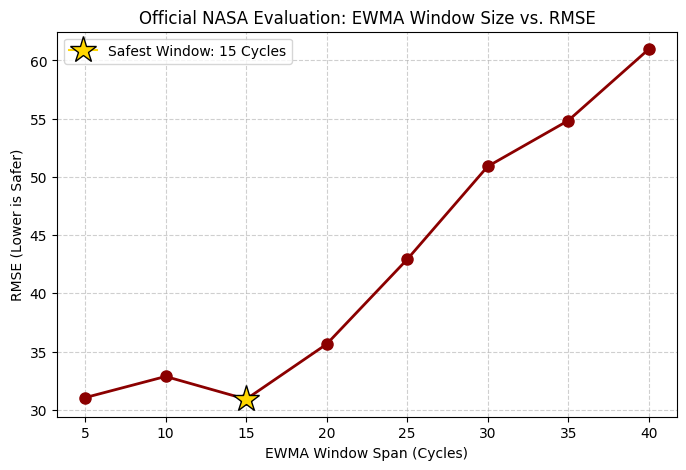

In [ ]:
# ---------------------------------------------------------
# VISUALIZE THE TRUE OPTIMAL WINDOW
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(window_sizes_to_test, rmses, marker='o', color='darkred', linewidth=2, markersize=8)
plt.title("Official NASA Evaluation: EWMA Window Size vs. RMSE")
plt.xlabel("EWMA Window Span (Cycles)")
plt.ylabel("RMSE (Lower is Safer)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(window_sizes_to_test)

best_idx = np.argmin(rmses)
plt.plot(window_sizes_to_test[best_idx], rmses[best_idx], marker='*', color='gold', markersize=20, markeredgecolor='black', label=f'Safest Window: {window_sizes_to_test[best_idx]} Cycles')
plt.legend()
plt.show()

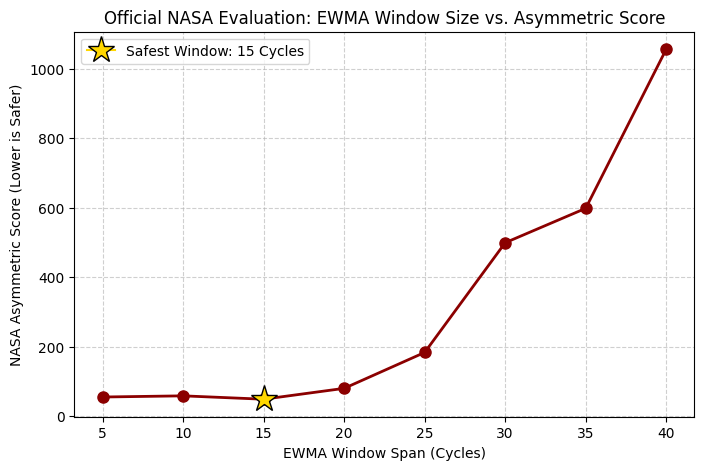

In [ ]:
# ---------------------------------------------------------
# VISUALIZE THE TRUE OPTIMAL WINDOW
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(window_sizes_to_test, asys, marker='o', color='darkred', linewidth=2, markersize=8)
plt.title("Official NASA Evaluation: EWMA Window Size vs. Asymmetric Score")
plt.xlabel("EWMA Window Span (Cycles)")
plt.ylabel("NASA Asymmetric Score (Lower is Safer)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(window_sizes_to_test)

best_idx = np.argmin(asys)
plt.plot(window_sizes_to_test[best_idx], asys[best_idx], marker='*', color='gold', markersize=20, markeredgecolor='black', label=f'Safest Window: {window_sizes_to_test[best_idx]} Cycles')
plt.legend()
plt.show()

# RUL Cap Validation

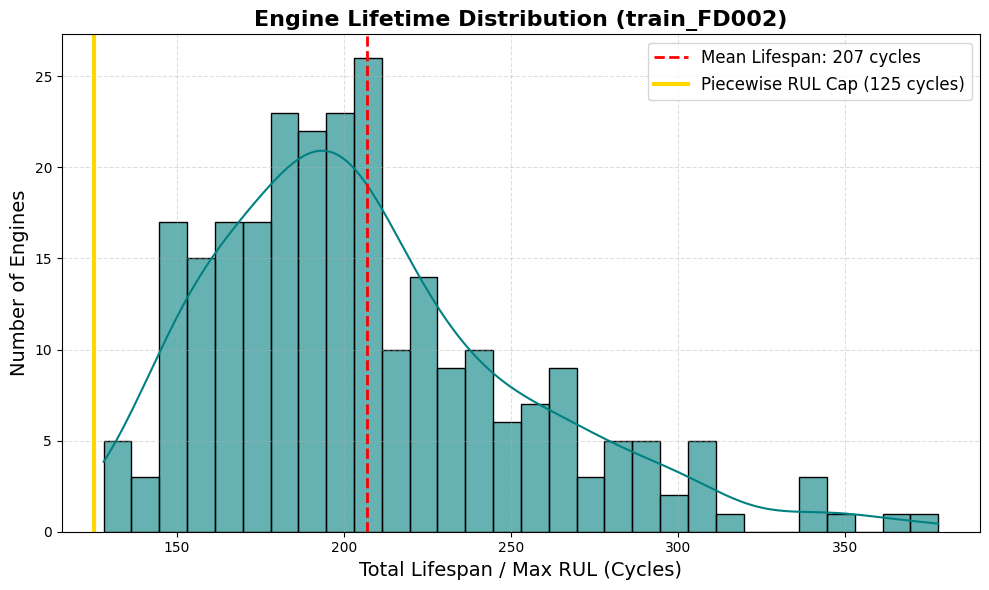

Shortest lifespan: 128 cycles
Longest lifespan: 378 cycles


In [ ]:
# 1. Calculate the maximum lifespan (Total RUL) for each of the 260 engines
engine_lifespans = train_2.groupby('unit')['cycle'].max()

# 2. Create the plot
plt.figure(figsize=(10, 6))

# Plot a histogram with a Kernel Density Estimate (KDE) curve overlaid
sns.histplot(engine_lifespans, bins=30, kde=True, color='teal', edgecolor='black', alpha=0.6)

# 3. Add vertical lines to tell the business/math story
mean_lifespan = engine_lifespans.mean()
min_lifespan = engine_lifespans.min()
max_lifespan = engine_lifespans.max()

plt.axvline(mean_lifespan, color='red', linestyle='dashed', linewidth=2,
            label=f'Mean Lifespan: {mean_lifespan:.0f} cycles')
plt.axvline(125, color='gold', linestyle='solid', linewidth=3,
            label='Piecewise RUL Cap (125 cycles)')

# 4. Formatting
plt.title('Engine Lifetime Distribution (train_FD002)', fontsize=16, fontweight='bold')
plt.xlabel('Total Lifespan / Max RUL (Cycles)', fontsize=14)
plt.ylabel('Number of Engines', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Shortest lifespan: {min_lifespan} cycles")
print(f"Longest lifespan: {max_lifespan} cycles")

In [ ]:
engine_lifespans.describe()

,cycle
count,260.000000
mean,206.765385
std,46.782198
min,128.000000
25%,174.000000
50%,199.000000
75%,230.250000
max,378.000000
